# IPL Model Training — FAST edition

A streamlined version of the multi-model benchmark, rebuilt for **speed** on the full ~234,000-row dataset (3,659 images \u00d7 64 cells) **without sacrificing model quality**. If the full notebook was taking many hours, this should finish in a fraction of the time.

**What makes it fast (and why each is safe):**

1. **Thread control** \u2014 caps CPU threads to avoid oversubscription/contention. Pure speed, zero effect on results.
2. **Lean, strong lineup** \u2014 keeps the models that actually win on tabular features (LightGBM, XGBoost, HistGB, Random Forest, + a fast Logistic-Regression baseline). **Drops the RBF SVM** (it was your slowest by far and wasn\u2019t leading) and CatBoost (accurate but was ~2.5 h/run \u2014 available behind a flag).
3. **Majority-class undersampling for training only** \u2014 ~85% of cells are \u201cNo Team.\u201d We thin those in the *training* folds so models train on far fewer rows, then **evaluate on the full, untouched holdout** so the reported numbers stay honest. This usually *improves* macro-F1 (less majority dominance) while cutting time.
4. **Faster booster settings + 3-fold CV** \u2014 trimmed estimator counts and early stopping where it doesn\u2019t hurt.

**Metrics:** per-cell **macro-F1** (headline) and **macro-F2** (favours recall \u2014 catching teams), plus **MCC**, balanced accuracy, and the **image-level team-set** scores (Jaccard + set-F1).


## 0. Install + thread control (run FIRST)

In [1]:
# Thread caps MUST be set before importing numpy/sklearn. Set N_THREADS to your
# machine's PHYSICAL core count (4 or 8 is typical on a laptop).
import os
N_THREADS = 4
for _v in ["OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS","VECLIB_MAXIMUM_THREADS"]:
    os.environ[_v] = str(N_THREADS)
print("Threads capped at", N_THREADS)


Threads capped at 4


In [2]:
%pip install -q lightgbm tqdm
print("ok (catboost only needed if you enable RUN_CATBOOST below)")


/Users/nikhiljha/Desktop/ipl-team-detection/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
ok (catboost only needed if you enable RUN_CATBOOST below)


## 1. Imports + progress helpers

In [3]:
import numpy as np, pandas as pd, time, warnings
from pathlib import Path
import joblib
warnings.filterwarnings("ignore")
from contextlib import contextmanager

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (RandomForestClassifier, HistGradientBoostingClassifier,
                              VotingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, fbeta_score, matthews_corrcoef,
                             balanced_accuracy_score, classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier; HAVE_LGBM = True
except Exception as e:
    HAVE_LGBM = False; print("LightGBM unavailable:", e)
import matplotlib.pyplot as plt, seaborn as sns

RANDOM_STATE = 42
GRID = 8                  # 8x8 = 64 cells per image
TEAM_MAP = {0:'No Team',1:'CSK',2:'DC',3:'GT',4:'KKR',5:'LSG',
            6:'MI',7:'PBKS',8:'RR',9:'RCB',10:'SRH'}

@contextmanager
def step(msg):
    print(f"\u23f3 {msg} ...", end="", flush=True); _t0=time.time()
    try: yield
    finally: print(f"\r\u2705 {msg} \u2014 done in {time.time()-_t0:.1f}s"+" "*8, flush=True)


## 2. Load features + clean NaNs

In [4]:
DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "features.csv")
feature_cols = [c for c in df.columns if c.startswith("f_")]
X = df[feature_cols].to_numpy(dtype=np.float32)
y = df["label"].astype(int).to_numpy()
groups = df["image_name"].to_numpy()

bad = (~np.isfinite(X)).sum()
if bad: print(f"Cleaning {bad} non-finite feature values -> 0")
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

num_classes = len(np.unique(y))
print("Rows:", X.shape, "| classes:", sorted(np.unique(y)),
      "| images:", pd.Series(groups).nunique())
print("Class-0 share: %.1f%%" % (100*(y==0).mean()))


Rows: (230720, 676) | classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] | images: 3605
Class-0 share: 83.6%


## 3. Image-aware split + majority undersampling (train only)

In [ ]:
# Holdout = untouched 20% of IMAGES -> honest evaluation on the real distribution.
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
tr, te = next(gss.split(X, y, groups))
X_train_full, y_train_full, g_train_full = X[tr], y[tr], groups[tr]
X_test, y_test, g_test = X[te], y[te], groups[te]

UNDERSAMPLE_RATIO = 2.0   # 'No Team' cells kept per team cell in TRAIN. 8GB RAM -> keep low (1.5-2). Higher = more data, more memory/time.
def undersample_majority(Xa, ya, ga, ratio, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    team = np.where(ya != 0)[0]
    bg   = np.where(ya == 0)[0]
    n_keep = min(len(bg), int(len(team) * ratio))
    keep = np.concatenate([team, rng.choice(bg, n_keep, replace=False)])
    rng.shuffle(keep)
    return Xa[keep], ya[keep], ga[keep]

X_train, y_train, g_train = undersample_majority(
    X_train_full, y_train_full, g_train_full, UNDERSAMPLE_RATIO)
print(f"Train rows: {len(y_train_full)} -> {len(y_train)} after undersampling "
      f"(ratio {UNDERSAMPLE_RATIO}).  Holdout rows: {len(y_test)} (full, untouched).")
print("Train class-0 share now: %.1f%%" % (100*(y_train==0).mean()))

# class weights from the (undersampled) training labels
classes = np.unique(y_train)
cw = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
sw_train = np.array([class_weight[int(c)] for c in y_train])

N_CV = 4
gkf = GroupKFold(n_splits=N_CV)


Train rows: 184576 -> 90702 after undersampling (ratio 2.0).  Holdout rows: 46144 (full, untouched).
Train class-0 share now: 66.7%


## 4. Lean, fast model zoo

In [6]:
RUN_CATBOOST = False   # set True to also benchmark CatBoost (slow: ~minutes-hours)

def make_models():
    m = {}
    if HAVE_LGBM:
        m["LightGBM"] = LGBMClassifier(            # fastest strong booster
            n_estimators=400, learning_rate=0.05, num_leaves=63,
            subsample=0.85, colsample_bytree=0.85, class_weight="balanced",
            n_jobs=N_THREADS, random_state=RANDOM_STATE, verbose=-1)
    m["XGBoost"] = XGBClassifier(
        objective="multi:softprob", num_class=num_classes, n_estimators=300,
        max_depth=7, learning_rate=0.1, subsample=0.85, colsample_bytree=0.85,
        eval_metric="mlogloss", tree_method="hist", n_jobs=N_THREADS,
        random_state=RANDOM_STATE)
    m["HistGB"] = HistGradientBoostingClassifier(  # built-in early stopping
        max_iter=300, learning_rate=0.1, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15, random_state=RANDOM_STATE)
    m["RandomForest"] = RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, class_weight="balanced_subsample",
        n_jobs=N_THREADS, random_state=RANDOM_STATE)
    m["LogReg"] = Pipeline([                        # fast linear baseline
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1500, class_weight="balanced",
                                  n_jobs=N_THREADS, random_state=RANDOM_STATE))])
    if RUN_CATBOOST:
        from catboost import CatBoostClassifier
        m["CatBoost"] = CatBoostClassifier(
            iterations=400, learning_rate=0.08, depth=8, loss_function="MultiClass",
            auto_class_weights="Balanced", thread_count=N_THREADS,
            random_seed=RANDOM_STATE, verbose=0)
    return m

def fit_one(name, model, Xtr, ytr, sw):
    if name in ("XGBoost", "HistGB"):
        try: model.fit(Xtr, ytr, sample_weight=sw); return model
        except TypeError: pass
    model.fit(Xtr, ytr); return model

print("Models:", list(make_models().keys()))


Models: ['LightGBM', 'XGBoost', 'HistGB', 'RandomForest', 'LogReg']


## 5. Metrics (macro-F1, macro-F2, MCC, image team-set)

In [7]:
def image_team_set_scores(yt, yp, grp):
    yt=np.asarray(yt); yp=np.asarray(yp); grp=np.asarray(grp)
    jacc, setf1 = [], []
    for g in np.unique(grp):
        mask = grp == g
        ts = set(int(t) for t in yt[mask] if t != 0)
        ps = set(int(t) for t in yp[mask] if t != 0)
        if not ts and not ps: jacc.append(1.0); setf1.append(1.0); continue
        inter=len(ts&ps); union=len(ts|ps)
        jacc.append(inter/union if union else 1.0)
        prec=inter/len(ps) if ps else 0.0; rec=inter/len(ts) if ts else 0.0
        setf1.append(2*prec*rec/(prec+rec) if (prec+rec) else 0.0)
    return float(np.mean(jacc)), float(np.mean(setf1))

def metrics_row(name, yt, yp, secs, grp=None):
    row = {"Model": name,
           "macroF1": f1_score(yt, yp, average="macro", zero_division=0),
           "macroF2": fbeta_score(yt, yp, beta=2, average="macro", zero_division=0),
           "MCC": matthews_corrcoef(yt, yp),
           "balAcc": balanced_accuracy_score(yt, yp),
           "accuracy": accuracy_score(yt, yp),
           "fit_sec": round(secs, 1)}
    if grp is not None:
        j, sf1 = image_team_set_scores(yt, yp, grp)
        row["img_Jaccard"]=j; row["img_setF1"]=sf1
    return row


## 6. Cross-validate the lineup (3-fold, group-aware)

Each model trains across 3 folds with a **progress bar** so you can see folds completing. Each fold's model is freed from memory immediately after use — important on an 8GB machine.

In [8]:
import gc
from tqdm.auto import tqdm

# Precompute fold splits once (reused for every model).
FOLDS = list(gkf.split(X_train, y_train, g_train))

def cv_predict_bar(name, sw=None):
    # Manual group-CV with a fold-by-fold progress bar. Frees each fold model
    # right away to keep peak memory low (matters a lot on 8GB).
    yp = np.empty(len(y_train), dtype=np.int16)
    use_sw = sw is not None and name in ("XGBoost", "HistGB")
    bar = tqdm(FOLDS, desc=f"{name}", leave=True, unit="fold")
    for ti, vi in bar:
        mdl = make_models()[name]                 # fresh estimator each fold
        if use_sw: mdl.fit(X_train[ti], y_train[ti], sample_weight=sw[ti])
        else:      mdl.fit(X_train[ti], y_train[ti])
        yp[vi] = mdl.predict(X_train[vi])
        del mdl; gc.collect()                     # release fold model immediately
    bar.close()
    return yp

_names = list(make_models().keys())
print(f"Cross-validating {len(_names)} models over {N_CV} folds on {len(y_train)} rows...\n")
_t = time.time(); cv_rows = []
for _k, name in enumerate(_names, 1):
    print(f"\u25b6 [{_k}/{len(_names)}] {name}")
    t0 = time.time()
    try:
        yp = cv_predict_bar(name, sw_train)
        cv_rows.append(metrics_row(name, y_train, yp, time.time()-t0, grp=g_train))
        r = cv_rows[-1]
        print(f"   \u2705 {name:13s} F1={r['macroF1']:.4f} F2={r['macroF2']:.4f} "
              f"MCC={r['MCC']:.4f} imgSetF1={r['img_setF1']:.4f} ({r['fit_sec']}s)\n")
    except Exception as e:
        print(f"   \u274c {name}: {e}\n")
    gc.collect()
print(f"Done in {time.time()-_t:.1f}s.")
_lead=["Model","macroF1","macroF2","MCC","img_setF1","img_Jaccard","balAcc","accuracy","fit_sec"]
cv_df = pd.DataFrame(cv_rows)[_lead].sort_values("macroF1", ascending=False).reset_index(drop=True)
print("\n=== Leaderboard (CV, sorted by macro-F1) ===")
cv_df.round(4)


Cross-validating 5 models over 3 folds on 90702 rows...

▶ [1/5] LightGBM


LightGBM:   0%|          | 0/3 [00:00<?, ?fold/s]

   ✅ LightGBM      F1=0.7128 F2=0.6890 MCC=0.6974 imgSetF1=0.7701 (1018.8s)

▶ [2/5] XGBoost


XGBoost:   0%|          | 0/3 [00:00<?, ?fold/s]

   ✅ XGBoost       F1=0.7123 F2=0.7021 MCC=0.6982 imgSetF1=0.7357 (1052.5s)

▶ [3/5] HistGB


...

RandomForest:   0%|          | 0/3 [00:00<?, ?fold/s]

   ✅ RandomForest  F1=0.5999 F2=0.5365 MCC=0.5919 imgSetF1=0.7736 (411.8s)

▶ [5/5] LogReg


LogReg:   0%|          | 0/3 [00:00<?, ?fold/s]

   ✅ LogReg        F1=0.5043 F2=0.5824 MCC=0.5035 imgSetF1=0.3844 (74.5s)

Done in 2780.3s.

=== Leaderboard (CV, sorted by macro-F1) ===


,Model,macroF1,macroF2,MCC,img_setF1,img_Jaccard,balAcc,accuracy,fit_sec
0,LightGBM,0.7128,0.6890,0.6974,0.7701,0.6887,0.6749,0.8419,1018.8
1,XGBoost,0.7123,0.7021,0.6982,0.7357,0.6433,0.6961,0.8390,1052.5
2,HistGB,0.6671,0.7096,0.6612,0.5736,0.4422,0.7428,0.7908,206.5
3,RandomForest,0.5999,0.5365,0.5919,0.7736,0.7110,0.5043,0.8007,411.8
4,LogReg,0.5043,0.5824,0.5035,0.3844,0.2496,0.6617,0.6354,74.5


## 7. Refit top models, evaluate on the FULL holdout

In [9]:
TOP_K = 3
top = cv_df["Model"].head(TOP_K).tolist()
print("Refitting + holdout-scoring:", top)
zoo = make_models(); fitted = {}
for name in top:
    with step(f"Refitting {name}"):
        fitted[name] = fit_one(name, zoo[name], X_train, y_train, sw_train)

# soft-voting ensemble of the top boosters (skip LogReg if present for speed/signal)
prob_top = [n for n in top if n != "LogReg"]
if len(prob_top) >= 2:
    with step("Fitting voting ensemble"):
        ens = VotingClassifier([(n, make_models()[n]) for n in prob_top], voting="soft", n_jobs=1)
        fitted["Voting(top)"] = fit_one("Voting", ens, X_train, y_train, sw_train)

hold = []
for name, model in fitted.items():
    with step(f"Scoring {name} on full holdout"):
        yp = model.predict(X_test)
    hold.append(metrics_row(name, y_test, yp, 0, grp=g_test))
hold_df = pd.DataFrame(hold)[_lead[:-1]].sort_values("macroF1", ascending=False).reset_index(drop=True)
print("\n=== Holdout (full, untouched distribution) ===")
hold_df.round(4)


Refitting + holdout-scoring: ['LightGBM', 'XGBoost', 'HistGB']
✅ Refitting LightGBM — done in 438.6s        
✅ Refitting XGBoost — done in 463.2s        
✅ Refitting HistGB — done in 131.0s        
✅ Fitting voting ensemble — done in 1184.8s        
✅ Scoring LightGBM on full holdout — done in 10.7s        
✅ Scoring XGBoost on full holdout — done in 0.9s        
✅ Scoring HistGB on full holdout — done in 3.4s        
✅ Scoring Voting(top) on full holdout — done in 17.3s        

=== Holdout (full, untouched distribution) ===


,Model,macroF1,macroF2,MCC,img_setF1,img_Jaccard,balAcc,accuracy
0,Voting(top),0.6642,0.6661,0.6453,0.7574,0.6689,0.6685,0.8921
1,LightGBM,0.6561,0.6914,0.6410,0.6761,0.5624,0.7188,0.8782
2,XGBoost,0.6389,0.6877,0.6286,0.6471,0.5272,0.7267,0.8683
3,HistGB,0.5485,0.6554,0.5551,0.4594,0.3174,0.7634,0.7915


## 8. Best model: confusion matrix + per-class report

BEST: Voting(top)
              precision    recall  f1-score   support

     No Team       0.94      0.94      0.94     38509
         CSK       0.63      0.79      0.70       685
          DC       0.64      0.54      0.59       330
          GT       0.55      0.56      0.56       567
         KKR       0.64      0.71      0.67       895
         LSG       0.69      0.58      0.63       522
          MI       0.63      0.74      0.68      1259
        PBKS       0.59      0.51      0.55       825
          RR       0.68      0.71      0.69       623
         RCB       0.63      0.60      0.61       663
         SRH       0.69      0.68      0.68      1266

    accuracy                           0.89     46144
   macro avg       0.67      0.67      0.66     46144
weighted avg       0.89      0.89      0.89     46144



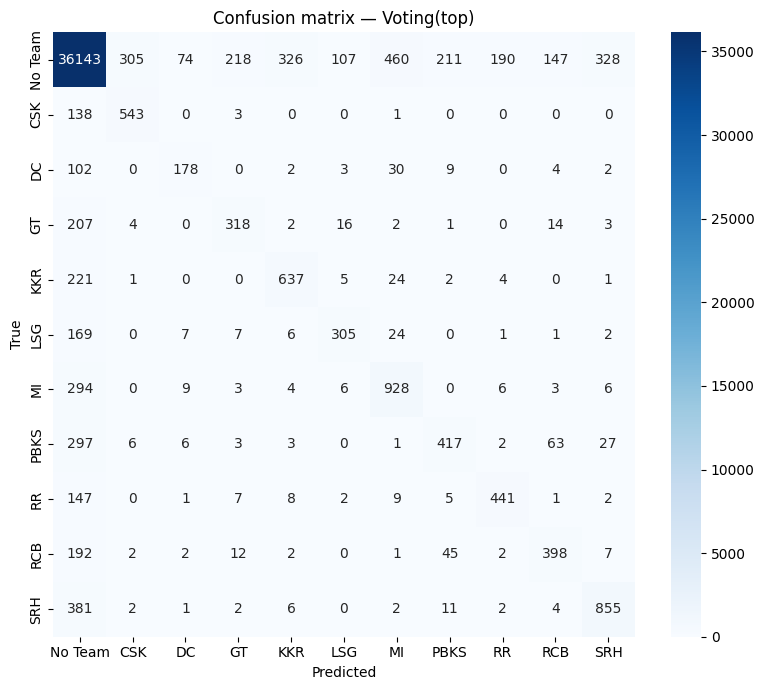

In [10]:
best_name = hold_df.iloc[0]["Model"]; best_model = fitted[best_name]
print("BEST:", best_name)
yp = best_model.predict(X_test)
labs = sorted(np.unique(y))
print(classification_report(y_test, yp, target_names=[TEAM_MAP[i] for i in labs], zero_division=0))
cm = confusion_matrix(y_test, yp, labels=labs)
plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[TEAM_MAP[i] for i in labs], yticklabels=[TEAM_MAP[i] for i in labs])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion matrix \u2014 {best_name}")
plt.tight_layout(); plt.show()


## 9. Save best model + write predictions CSV

In [11]:
TEAM_NAME = "teamname"     # <-- your team name
joblib.dump(best_model, Path(f"model_{TEAM_NAME}.pkl"))
print("Saved model_%s.pkl (%s)" % (TEAM_NAME, best_name))

with step("Predicting every cell for the predictions CSV"):
    pred_all = best_model.predict(X)
out = df[["image_name","cell_id"]].copy(); out["pred"]=pred_all
out["split"]="Train"; out.loc[np.isin(np.arange(len(df)), te), "split"]="Test"
wide = out.pivot_table(index=["image_name","split"], columns="cell_id",
                       values="pred", aggfunc="first").reset_index()
wide.columns = ["Image File Name","Train Or Test"] + [f"c{int(c):02d}" for c in wide.columns[2:]]
for i in range(1,65):
    if f"c{i:02d}" not in wide.columns: wide[f"c{i:02d}"]=0
wide = wide[["Image File Name","Train Or Test"]+[f"c{i:02d}" for i in range(1,65)]]
wide.iloc[:,2:] = wide.iloc[:,2:].fillna(0).astype(int)
wide.to_csv("predictions.csv", index=False)
print("Wrote predictions.csv", wide.shape)
wide.head()


Saved model_teamname.pkl (Voting(top))
✅ Predicting every cell for the predictions CSV — done in 73.3s        
Wrote predictions.csv (3605, 66)


,Image File Name,Train Or Test,c01,c02,c03,c04,c05,c06,c07,c08,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,c64
0,GTvsLSG_image_0.jpg,Test,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,GTvsLSG_image_1.jpg,Train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,GTvsLSG_image_10.jpg,Train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,GTvsLSG_image_11.jpg,Train,0,0,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,GTvsLSG_image_12.jpg,Train,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,5,0,0


## 10. Count the number of players per image

The project asks us to **count players**, not just classify cells. Since deep-learning object detectors are off-limits, we derive the count from the per-cell grid the model already produces: each **connected group of same-team cells** (4-connectivity on the 8\u00d78 grid) is treated as one player, and we sum across teams.

**Honest limitations (state these in your slides):**
- Two players of the **same team** standing adjacent merge into one blob \u2192 the count can be an **under-count** in crowded same-team scenes.
- The "true" count here is itself derived from the ground-truth grid the same way, so this measures how well the predicted grid reproduces the count structure \u2014 not a perfect head-count.
- It works best for distinct, separated players of different teams.

In [12]:
def count_players_from_grid(grid):
    # grid: length-64 (or 8x8) array of team labels 0..10.
    # Count connected same-team regions (4-connectivity); each = one player.
    g = np.asarray(grid).reshape(GRID, GRID)
    seen = np.zeros_like(g, dtype=bool)
    n = 0
    for r in range(GRID):
        for c in range(GRID):
            t = g[r, c]
            if t == 0 or seen[r, c]:
                continue
            n += 1                          # new player blob
            stack = [(r, c)]; seen[r, c] = True
            while stack:                    # flood-fill same-team neighbours
                y, x = stack.pop()
                for dy, dx in ((1,0),(-1,0),(0,1),(0,-1)):
                    ny, nx = y+dy, x+dx
                    if 0 <= ny < GRID and 0 <= nx < GRID and not seen[ny, nx] and g[ny, nx] == t:
                        seen[ny, nx] = True; stack.append((ny, nx))
    return n

# Build per-image grids from PREDICTED labels (wide table) and TRUE labels (df).
cell_cols = [f"c{i:02d}" for i in range(1, 65)]
pred_counts, true_counts, names, splits = [], [], [], []
true_grid_by_img = (df.sort_values("cell_id")
                      .groupby("image_name")["label"].apply(lambda s: s.to_numpy()))
for _, row in wide.iterrows():
    img = row["Image File Name"]
    pred_grid = row[cell_cols].to_numpy().astype(int)
    pred_counts.append(count_players_from_grid(pred_grid))
    tg = true_grid_by_img.get(img)
    true_counts.append(count_players_from_grid(tg) if tg is not None and len(tg) == 64 else np.nan)
    names.append(img); splits.append(row["Train Or Test"])

counts_df = pd.DataFrame({"Image File Name": names, "Train Or Test": splits,
                          "Predicted_Player_Count": pred_counts,
                          "TrueGrid_Player_Count": true_counts})
counts_df.to_csv("player_counts.csv", index=False)
print("Wrote player_counts.csv", counts_df.shape)
counts_df.head()


Wrote player_counts.csv (3605, 4)


,Image File Name,Train Or Test,Predicted_Player_Count,TrueGrid_Player_Count
0,GTvsLSG_image_0.jpg,Test,3,1
1,GTvsLSG_image_1.jpg,Train,2,1
2,GTvsLSG_image_10.jpg,Train,2,2
3,GTvsLSG_image_11.jpg,Train,2,1
4,GTvsLSG_image_12.jpg,Train,2,1


ALL    | MAE=0.84  RMSE=1.55  exact=53.7%  within±1=81.1%  (n=3605)
TRAIN  | MAE=0.66  RMSE=1.27  exact=59.4%  within±1=85.4%  (n=2884)
TEST   | MAE=1.54  RMSE=2.35  exact=30.9%  within±1=63.8%  (n=721)


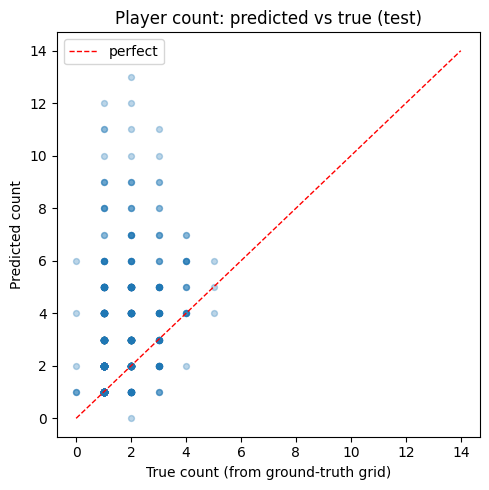

In [13]:
# Evaluate counting on the TEST images (held-out), against grid-derived true counts.
ev = counts_df.dropna(subset=["TrueGrid_Player_Count"])
ev_test = ev[ev["Train Or Test"] == "Test"]
def count_metrics(d, tag):
    if len(d) == 0:
        print(f"{tag}: no rows"); return
    p = d["Predicted_Player_Count"].to_numpy()
    t = d["TrueGrid_Player_Count"].to_numpy()
    mae = np.mean(np.abs(p - t)); rmse = np.sqrt(np.mean((p - t)**2))
    exact = np.mean(p == t); within1 = np.mean(np.abs(p - t) <= 1)
    print(f"{tag:6s} | MAE={mae:.2f}  RMSE={rmse:.2f}  exact={exact:.1%}  within\u00b11={within1:.1%}  (n={len(d)})")
count_metrics(ev, "ALL")
count_metrics(ev[ev['Train Or Test']=='Train'], "TRAIN")
count_metrics(ev_test, "TEST")

# Scatter: predicted vs true count (test)
if len(ev_test):
    plt.figure(figsize=(5,5))
    mx = int(max(ev_test["Predicted_Player_Count"].max(), ev_test["TrueGrid_Player_Count"].max())) + 1
    plt.scatter(ev_test["TrueGrid_Player_Count"], ev_test["Predicted_Player_Count"],
                alpha=0.3, s=18)
    plt.plot([0, mx], [0, mx], "r--", lw=1, label="perfect")
    plt.xlabel("True count (from ground-truth grid)"); plt.ylabel("Predicted count")
    plt.title("Player count: predicted vs true (test)"); plt.legend()
    plt.tight_layout(); plt.show()


## 11. Tuning (optional, do this on ONE model only)

Tuning is expensive (each trial = a full CV). On this data, only tune the **single best** model with a small trial budget. Uncomment to run.

In [ ]:
# %pip install -q optuna
# import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
# N_TRIALS = 12
# def objective(trial):
#     model = LGBMClassifier(
#         n_estimators=trial.suggest_int("n_estimators",300,800,step=100),
#         num_leaves=trial.suggest_int("num_leaves",31,150),
#         learning_rate=trial.suggest_float("learning_rate",0.02,0.2,log=True),
#         subsample=trial.suggest_float("subsample",0.7,1.0),
#         colsample_bytree=trial.suggest_float("colsample_bytree",0.7,1.0),
#         class_weight="balanced", n_jobs=N_THREADS, random_state=RANDOM_STATE, verbose=-1)
#     yp = cv_predict_bar.__wrapped__ if False else None  # (see note)
#     # quick inline CV for tuning (no bar): fit per fold
#     import numpy as _np
#     yp = _np.empty(len(y_train), dtype=_np.int16)
#     for _ti,_vi in FOLDS:
#         model.fit(X_train[_ti], y_train[_ti]); yp[_vi] = model.predict(X_train[_vi])
#     return f1_score(y_train, yp, average="macro", zero_division=0)
# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
# print("best macroF1:", study.best_value, "\nparams:", study.best_params)


## Notes on the speed/quality trade-offs

- **8GB RAM (e.g. M1 MacBook Air)**: memory swap, not slow CPU, is usually the bottleneck. Keep `UNDERSAMPLE_RATIO` at 1.5\u20132.0, set `N_THREADS = 4` (the M1\u2019s 4 performance cores; using all 8 can be slower), close other apps, and watch Activity Monitor \u2192 Memory: yellow/red pressure means it\u2019s swapping. Each fold\u2019s model is freed immediately to keep peak memory low.
- **Thread cap (`N_THREADS`)**: set it to your physical performance-core count.
- **`UNDERSAMPLE_RATIO`**: 3.0 is conservative. Lower it (2.0, 1.5) for more speed; the holdout (full distribution) tells you honestly if macro-F1 drops. It often *rises*.
- **Holdout is never undersampled**, so the reported macro-F1 / F2 / MCC reflect real performance.
- If you want CatBoost in the mix, set `RUN_CATBOOST = True` (expect it to be the slow one).
- **macro-F2** is reported next to macro-F1: F2 weights recall higher, i.e. it rewards *catching* teams even at some precision cost \u2014 useful if missing a team is worse than a false alarm.
